# Fig.1b Non-Kohler Solver for TEM Condenser Stack (CL1/CL2/Cmini)

This notebook mirrors the workflow style of `kohler_condenser_tem.ipynb` but models the **non-Kohler** Fig.1b chain:

- Optics: `S -> CL1 -> CL2 -> A -> Cmini -> OPL -> Sp`
- `Cmini` focal length is fixed (`f_Cmini_fixed`)
- Geometry and `f_OPL` reuse values from the existing Kohler notebook

Two non-Kohler branches are solved with root-finding:

1. **Wide-area branch**: crossover imaged at aperture plane
   - `B(S->A) = 0`
   - `A(S->A) = M_A_target`

2. **Focused branch**: crossover imaged at specimen plane
   - `B(S->Sp) = 0`
   - `A(S->Sp) = M_Sp_target`

A non-Kohler sanity check is included by evaluating `B(S->F_OPL)`, where `F_OPL` is the front focal plane of OPL.


## 1) Setup, conventions, and helper utilities

We use paraxial state `r = [x, theta]^T` and 2x2 transfer matrices:

- Drift: `P(d) = [[1, d], [0, 1]]`
- Thin lens: `L(f) = [[1, 0], [-1/f, 1]]`

Conventions:

- Distances in chain assembly are downstream-positive.
- Focal lengths are constrained positive in numerical solves.
- `f_Cmini_fixed` is held constant while solving `(f_CL1, f_CL2)`.


In [1]:
import sys
from pathlib import Path

_repo_root = Path.cwd()
_src = _repo_root / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

from pprint import pprint

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

try:
    import jax
    jax.config.update("jax_enable_x64", True)
    import jax.numpy as jnp
except Exception:
    jax = None
    jnp = None

try:
    import optimistix as optx
    OPTIMISTIX_AVAILABLE = True
except Exception:
    optx = None
    OPTIMISTIX_AVAILABLE = False

if jnp is None:
    OPTIMISTIX_AVAILABLE = False

sp.init_printing()
print("optimistix available:", OPTIMISTIX_AVAILABLE)


def P_num(d):
    return np.array([[1.0, float(d)], [0.0, 1.0]], dtype=float)


def L_num(f):
    return np.array([[1.0, 0.0], [-1.0 / float(f), 1.0]], dtype=float)


def compose_forward_num(ops):
    M = np.eye(2, dtype=float)
    for op in ops:
        M = np.asarray(op, dtype=float) @ M
    return M


def apply_ray_matrix(M, x, theta):
    v = np.array([x, theta], dtype=float)
    out = np.asarray(M, dtype=float) @ v
    return float(out[0]), float(out[1])


optimistix available: True


## 2) Config/defaults

Defaults reuse geometry from `kohler_condenser_tem.ipynb` with variable renames:

- `d_C1_C3 -> d_C1_C2`
- `d_C3_A -> d_C2_A`

`f_Cmini_fixed` is provided explicitly and remains fixed during branch solves.


In [2]:
cfg_non_kohler = {
    # Fixed OPL optics
    "f_OPL": 5.0e-3,
    "d_OPL_Sp": 1.0e-3,

    # Reused geometry (renamed to CL1/CL2 notation)
    "d_S_C1": 0.2,
    "d_C1_C2": 0.3,
    "d_C2_A": 0.1,
    "d_A_Cmini": 0.3,
    "d_Cmini_OPL": 0.1,

    # Cmini fixed setting for non-Kohler study
    # Chosen for direct comparability with prior explored settings.
    "f_Cmini_fixed": 1e-2,

    # Branch target sweeps (magnification-like A-entry targets)
    "M_A_sweep": np.array([-10.0, -8.0, -6.0, -5.0, -4.0, -3.0, -2.0, -1.0, 1.0, 2.0, 3.0, 4.0, 6.0, 8.0, 10.0], dtype=float),
    "M_Sp_sweep": np.array([-10.0, -8.0, -6.0, -5.0, -4.0, -3.0, -2.0, -1.0, 1.0, 2.0, 3.0, 4.0, 6.0, 8.0, 10.0], dtype=float),

    # Acceptance and search controls
    "residual_tol_accept": 1.0e-9,
    "multistart_n_seeds": 64,
    "multistart_seed": 17,
    "multistart_residual_tol": 1.0e-9,
}

bounds_non_kohler = {
    "f_CL1": (0.5e-3, 25.0e-3),
    # Broad lower bound to allow sub-mm CL2 solutions under reused geometry
    "f_CL2": (0.05e-3, 25.0e-3),
}

x0_branch = np.array([1.6e-3, 0.6e-3], dtype=float)

print("Configuration:")
pprint(cfg_non_kohler)
print("\nBounds:")
pprint(bounds_non_kohler)


Configuration:
{'M_A_sweep': array([-10.,  -8.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   1.,   2.,   3.,
         4.,   6.,   8.,  10.]),
 'M_Sp_sweep': array([-10.,  -8.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   1.,   2.,   3.,
         4.,   6.,   8.,  10.]),
 'd_A_Cmini': 0.3,
 'd_C1_C2': 0.3,
 'd_C2_A': 0.1,
 'd_Cmini_OPL': 0.1,
 'd_OPL_Sp': 0.001,
 'd_S_C1': 0.2,
 'f_Cmini_fixed': 0.01,
 'f_OPL': 0.005,
 'multistart_n_seeds': 64,
 'multistart_residual_tol': 1e-09,
 'multistart_seed': 17,
 'residual_tol_accept': 1e-09}

Bounds:
{'f_CL1': (0.0005, 0.025), 'f_CL2': (5e-05, 0.025)}


## 3) Symbolic derivation (SymPy)

We build symbolic matrices for:

- `M_SA`: source to aperture plane
- `M_SSp`: source to specimen plane (through fixed Cmini + OPL)
- `M_SF`: source to OPL front focal plane (`F_OPL`) for non-Kohler sanity checks

From each, we extract and lambdify `A` and `B`.


M_S->A:


⎡-d_C1_C2⋅f_CL2 + d_C2_A⋅(d_C1_C2 - f_CL1 - f_CL2) + f_CL1⋅f_CL2  -d_C1_C2⋅f_C ↪
⎢───────────────────────────────────────────────────────────────  ──────────── ↪
⎢                          f_CL1⋅f_CL2                                         ↪
⎢                                                                              ↪
⎢                    d_C1_C2 - f_CL1 - f_CL2                                   ↪
⎢                    ───────────────────────                                   ↪
⎣                          f_CL1⋅f_CL2                                         ↪

↪ L2⋅(d_S_C1 - f_CL1) - d_C2_A⋅(-d_C1_C2⋅(d_S_C1 - f_CL1) + d_S_C1⋅f_CL1 + d_S ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                                                  f_CL1⋅f_CL2                 ↪
↪                                                                              ↪
↪                     d_C1_C2⋅(d_S_C1 - f_CL1) - d_S_C1⋅f_CL1 - d_S_C1⋅f_CL2 + ↪
↪                     ─────


M_S->Sp:


⎡-d_C1_C2⋅f_CL2⋅f_Cmini⋅f_OPL - d_Cmini_OPL⋅f_OPL⋅(-d_C1_C2⋅f_CL2 + f_CL1⋅f_CL ↪
⎢───────────────────────────────────────────────────────────────────────────── ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎣                                                                              ↪

↪ 2 + f_CL2⋅f_Cmini + f_Cmini⋅(-d_C1_C2 + f_CL1) - (d_A_Cmini + d_C2_A)⋅(-d_C1 ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                                                                              ↪
↪                                                                              ↪
↪                                                                d_C1_C2⋅f_CL2 ↪
↪                          


M_S->F_OPL:


⎡-d_C1_C2⋅f_CL2⋅f_Cmini + f_CL1⋅f_CL2⋅f_Cmini + f_Cmini⋅(d_A_Cmini + d_C2_A)⋅( ↪
⎢───────────────────────────────────────────────────────────────────────────── ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                 d_C1_C2⋅f_CL ↪
⎢                                                                 ──────────── ↪
⎣                                                                              ↪

↪ d_C1_C2 - f_CL1 - f_CL2) - (d_Cmini_OPL - f_OPL)⋅(-d_C1_C2⋅f_CL2 + f_CL1⋅f_C ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                                        f_CL1⋅f_CL2⋅f_Cmini                   ↪
↪                                                                              ↪
↪ 2 - f_CL1⋅f_CL2 - f_CL2⋅f_Cmini + f_Cmini⋅(d_C1_C2 - f_CL1) + (d_A_Cmini + d ↪
↪ ─────────────────────────


Branch constraints used in solves:


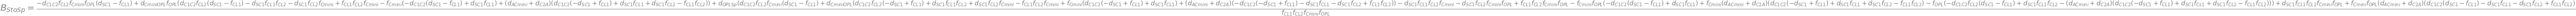


Non-Kohler sanity quantity:


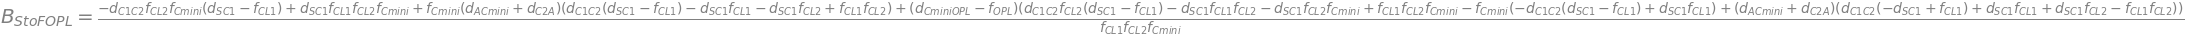


Lambdified functions ready.


In [3]:
# Symbols
sym_d_S_C1, sym_d_C1_C2, sym_d_C2_A, sym_d_A_Cmini, sym_d_Cmini_OPL, sym_d_OPL_Sp = sp.symbols(
    "d_S_C1 d_C1_C2 d_C2_A d_A_Cmini d_Cmini_OPL d_OPL_Sp", positive=True, finite=True
)
sym_f_CL1, sym_f_CL2, sym_f_Cmini, sym_f_OPL = sp.symbols(
    "f_CL1 f_CL2 f_Cmini f_OPL", positive=True, finite=True
)


def P_sym(d):
    return sp.Matrix([[1, d], [0, 1]])


def L_sym(f):
    return sp.Matrix([[1, 0], [-1 / f, 1]])


def compose_forward_sym(ops):
    M = sp.eye(2)
    for op in ops:
        M = op @ M
    return sp.simplify(M)


M_S_to_A_sym = compose_forward_sym([
    P_sym(sym_d_S_C1),
    L_sym(sym_f_CL1),
    P_sym(sym_d_C1_C2),
    L_sym(sym_f_CL2),
    P_sym(sym_d_C2_A),
])

M_S_to_Sp_sym = compose_forward_sym([
    P_sym(sym_d_S_C1),
    L_sym(sym_f_CL1),
    P_sym(sym_d_C1_C2),
    L_sym(sym_f_CL2),
    P_sym(sym_d_C2_A),
    P_sym(sym_d_A_Cmini),
    L_sym(sym_f_Cmini),
    P_sym(sym_d_Cmini_OPL),
    L_sym(sym_f_OPL),
    P_sym(sym_d_OPL_Sp),
])

M_S_to_F_sym = compose_forward_sym([
    P_sym(sym_d_S_C1),
    L_sym(sym_f_CL1),
    P_sym(sym_d_C1_C2),
    L_sym(sym_f_CL2),
    P_sym(sym_d_C2_A),
    P_sym(sym_d_A_Cmini),
    L_sym(sym_f_Cmini),
    P_sym(sym_d_Cmini_OPL - sym_f_OPL),
])

A_SA_sym, B_SA_sym = sp.simplify(M_S_to_A_sym[0, 0]), sp.simplify(M_S_to_A_sym[0, 1])
A_SSp_sym, B_SSp_sym = sp.simplify(M_S_to_Sp_sym[0, 0]), sp.simplify(M_S_to_Sp_sym[0, 1])
A_SF_sym, B_SF_sym = sp.simplify(M_S_to_F_sym[0, 0]), sp.simplify(M_S_to_F_sym[0, 1])

print("M_S->A:")
display(M_S_to_A_sym)
print("\nM_S->Sp:")
display(M_S_to_Sp_sym)
print("\nM_S->F_OPL:")
display(M_S_to_F_sym)

print("\nBranch constraints used in solves:")
display(sp.Eq(sp.Symbol("B_S_to_A"), B_SA_sym))
display(sp.Eq(sp.Symbol("B_S_to_Sp"), B_SSp_sym))

print("\nNon-Kohler sanity quantity:")
display(sp.Eq(sp.Symbol("B_S_to_F_OPL"), B_SF_sym))

# Lambdified numeric functions (NumPy backend)
A_SA_num = sp.lambdify(
    (sym_d_S_C1, sym_d_C1_C2, sym_d_C2_A, sym_f_CL1, sym_f_CL2),
    A_SA_sym,
    "numpy",
)
B_SA_num = sp.lambdify(
    (sym_d_S_C1, sym_d_C1_C2, sym_d_C2_A, sym_f_CL1, sym_f_CL2),
    B_SA_sym,
    "numpy",
)

A_SSp_num = sp.lambdify(
    (sym_d_S_C1, sym_d_C1_C2, sym_d_C2_A, sym_d_A_Cmini, sym_d_Cmini_OPL, sym_d_OPL_Sp, sym_f_CL1, sym_f_CL2, sym_f_Cmini, sym_f_OPL),
    A_SSp_sym,
    "numpy",
)
B_SSp_num = sp.lambdify(
    (sym_d_S_C1, sym_d_C1_C2, sym_d_C2_A, sym_d_A_Cmini, sym_d_Cmini_OPL, sym_d_OPL_Sp, sym_f_CL1, sym_f_CL2, sym_f_Cmini, sym_f_OPL),
    B_SSp_sym,
    "numpy",
)

A_SF_num = sp.lambdify(
    (sym_d_S_C1, sym_d_C1_C2, sym_d_C2_A, sym_d_A_Cmini, sym_d_Cmini_OPL, sym_f_CL1, sym_f_CL2, sym_f_Cmini, sym_f_OPL),
    A_SF_sym,
    "numpy",
)
B_SF_num = sp.lambdify(
    (sym_d_S_C1, sym_d_C1_C2, sym_d_C2_A, sym_d_A_Cmini, sym_d_Cmini_OPL, sym_f_CL1, sym_f_CL2, sym_f_Cmini, sym_f_OPL),
    B_SF_sym,
    "numpy",
)

print("\nLambdified functions ready.")


## 4) Numeric evaluators and branch residuals

Residual definitions:

- `residual_wide(x, M_A_target) = [B_SA, A_SA - M_A_target]`
- `residual_focused(x, M_Sp_target) = [B_SSp, A_SSp - M_Sp_target]`

Unknowns are `x = [f_CL1, f_CL2]`.


In [4]:
def eval_A_SA(f_cl1, f_cl2, cfg_local):
    return float(
        A_SA_num(
            cfg_local["d_S_C1"],
            cfg_local["d_C1_C2"],
            cfg_local["d_C2_A"],
            f_cl1,
            f_cl2,
        )
    )


def eval_B_SA(f_cl1, f_cl2, cfg_local):
    return float(
        B_SA_num(
            cfg_local["d_S_C1"],
            cfg_local["d_C1_C2"],
            cfg_local["d_C2_A"],
            f_cl1,
            f_cl2,
        )
    )


def eval_A_SSp(f_cl1, f_cl2, cfg_local):
    return float(
        A_SSp_num(
            cfg_local["d_S_C1"],
            cfg_local["d_C1_C2"],
            cfg_local["d_C2_A"],
            cfg_local["d_A_Cmini"],
            cfg_local["d_Cmini_OPL"],
            cfg_local["d_OPL_Sp"],
            f_cl1,
            f_cl2,
            cfg_local["f_Cmini_fixed"],
            cfg_local["f_OPL"],
        )
    )


def eval_B_SSp(f_cl1, f_cl2, cfg_local):
    return float(
        B_SSp_num(
            cfg_local["d_S_C1"],
            cfg_local["d_C1_C2"],
            cfg_local["d_C2_A"],
            cfg_local["d_A_Cmini"],
            cfg_local["d_Cmini_OPL"],
            cfg_local["d_OPL_Sp"],
            f_cl1,
            f_cl2,
            cfg_local["f_Cmini_fixed"],
            cfg_local["f_OPL"],
        )
    )


def eval_B_SFOPL(f_cl1, f_cl2, cfg_local):
    return float(
        B_SF_num(
            cfg_local["d_S_C1"],
            cfg_local["d_C1_C2"],
            cfg_local["d_C2_A"],
            cfg_local["d_A_Cmini"],
            cfg_local["d_Cmini_OPL"],
            f_cl1,
            f_cl2,
            cfg_local["f_Cmini_fixed"],
            cfg_local["f_OPL"],
        )
    )


def residual_wide(x, M_A_target, cfg_local):
    f_cl1, f_cl2 = float(x[0]), float(x[1])
    r1 = eval_B_SA(f_cl1, f_cl2, cfg_local)
    r2 = eval_A_SA(f_cl1, f_cl2, cfg_local) - float(M_A_target)
    return np.array([r1, r2], dtype=float)


def residual_focused(x, M_Sp_target, cfg_local):
    f_cl1, f_cl2 = float(x[0]), float(x[1])
    r1 = eval_B_SSp(f_cl1, f_cl2, cfg_local)
    r2 = eval_A_SSp(f_cl1, f_cl2, cfg_local) - float(M_Sp_target)
    return np.array([r1, r2], dtype=float)


# JAX evaluators for optimistix

def P_jax(d):
    return jnp.array([[1.0, d], [0.0, 1.0]], dtype=jnp.float64)


def L_jax(f):
    return jnp.array([[1.0, 0.0], [-1.0 / f, 1.0]], dtype=jnp.float64)


def compose_forward_jax(ops):
    M = jnp.eye(2, dtype=jnp.float64)
    for op in ops:
        M = op @ M
    return M


def eval_A_SA_jax(f_cl1, f_cl2, cfg_local):
    M = compose_forward_jax([
        P_jax(cfg_local["d_S_C1"]),
        L_jax(f_cl1),
        P_jax(cfg_local["d_C1_C2"]),
        L_jax(f_cl2),
        P_jax(cfg_local["d_C2_A"]),
    ])
    return M[0, 0]


def eval_B_SA_jax(f_cl1, f_cl2, cfg_local):
    M = compose_forward_jax([
        P_jax(cfg_local["d_S_C1"]),
        L_jax(f_cl1),
        P_jax(cfg_local["d_C1_C2"]),
        L_jax(f_cl2),
        P_jax(cfg_local["d_C2_A"]),
    ])
    return M[0, 1]


def eval_A_SSp_jax(f_cl1, f_cl2, cfg_local):
    M = compose_forward_jax([
        P_jax(cfg_local["d_S_C1"]),
        L_jax(f_cl1),
        P_jax(cfg_local["d_C1_C2"]),
        L_jax(f_cl2),
        P_jax(cfg_local["d_C2_A"]),
        P_jax(cfg_local["d_A_Cmini"]),
        L_jax(cfg_local["f_Cmini_fixed"]),
        P_jax(cfg_local["d_Cmini_OPL"]),
        L_jax(cfg_local["f_OPL"]),
        P_jax(cfg_local["d_OPL_Sp"]),
    ])
    return M[0, 0]


def eval_B_SSp_jax(f_cl1, f_cl2, cfg_local):
    M = compose_forward_jax([
        P_jax(cfg_local["d_S_C1"]),
        L_jax(f_cl1),
        P_jax(cfg_local["d_C1_C2"]),
        L_jax(f_cl2),
        P_jax(cfg_local["d_C2_A"]),
        P_jax(cfg_local["d_A_Cmini"]),
        L_jax(cfg_local["f_Cmini_fixed"]),
        P_jax(cfg_local["d_Cmini_OPL"]),
        L_jax(cfg_local["f_OPL"]),
        P_jax(cfg_local["d_OPL_Sp"]),
    ])
    return M[0, 1]


def residual_wide_u_jax(u, args):
    M_A_target, cfg_local, bounds_arr = args
    x = bounded_logistic_to_physical_jax(u, bounds_arr)
    f_cl1, f_cl2 = x[0], x[1]
    r1 = eval_B_SA_jax(f_cl1, f_cl2, cfg_local)
    r2 = eval_A_SA_jax(f_cl1, f_cl2, cfg_local) - M_A_target
    return jnp.array([r1, r2], dtype=jnp.float64)


def residual_focused_u_jax(u, args):
    M_Sp_target, cfg_local, bounds_arr = args
    x = bounded_logistic_to_physical_jax(u, bounds_arr)
    f_cl1, f_cl2 = x[0], x[1]
    r1 = eval_B_SSp_jax(f_cl1, f_cl2, cfg_local)
    r2 = eval_A_SSp_jax(f_cl1, f_cl2, cfg_local) - M_Sp_target
    return jnp.array([r1, r2], dtype=jnp.float64)


def bounded_logistic_to_physical_np(u, bounds_arr):
    bounds_arr = np.asarray(bounds_arr, dtype=float)
    lo = bounds_arr[:, 0]
    hi = bounds_arr[:, 1]
    u_arr = np.asarray(u, dtype=float)
    u_clip = np.clip(u_arr, -60.0, 60.0)
    s = 1.0 / (1.0 + np.exp(-u_clip))
    return lo + (hi - lo) * s


def bounded_logit_from_physical_np(x, bounds_arr):
    bounds_arr = np.asarray(bounds_arr, dtype=float)
    lo = bounds_arr[:, 0]
    hi = bounds_arr[:, 1]
    s = np.clip((np.asarray(x, dtype=float) - lo) / (hi - lo), 1e-9, 1.0 - 1e-9)
    return np.log(s) - np.log1p(-s)


def bounded_logistic_to_physical_jax(u, bounds_arr):
    bounds_arr_j = jnp.asarray(bounds_arr, dtype=jnp.float64)
    lo = bounds_arr_j[:, 0]
    hi = bounds_arr_j[:, 1]
    return lo + (hi - lo) * jax.nn.sigmoid(u)


def solve_2eq_optimistix_lm(residual_u_jax, args, bounds_arr, x0, tol=1e-12, max_steps=220):
    if not OPTIMISTIX_AVAILABLE:
        return {
            "success": False,
            "status": "optimistix_unavailable",
            "x": np.asarray(x0, dtype=float),
            "iterations": 0,
            "result": None,
        }

    bounds_arr = np.asarray(bounds_arr, dtype=float)
    x0_clipped = np.clip(np.asarray(x0, dtype=float), bounds_arr[:, 0], bounds_arr[:, 1])
    u0 = bounded_logit_from_physical_np(x0_clipped, bounds_arr)

    try:
        solver = optx.LevenbergMarquardt(rtol=tol, atol=tol)
        sol = optx.root_find(
            residual_u_jax,
            solver,
            y0=jnp.asarray(u0, dtype=jnp.float64),
            args=args,
            options={"jac": "fwd"},
            max_steps=max_steps,
            throw=False,
        )
        u_star = np.asarray(sol.value, dtype=float)
        x_star = bounded_logistic_to_physical_np(u_star, bounds_arr)
        return {
            "success": bool(sol.result == optx.RESULTS.successful),
            "status": str(sol.result),
            "x": x_star,
            "iterations": int(np.asarray(sol.stats.get("num_steps", 0))),
            "result": sol,
        }
    except Exception as exc:
        return {
            "success": False,
            "status": f"optimistix_exception:{type(exc).__name__}",
            "x": x0_clipped,
            "iterations": 0,
            "result": None,
        }


def fd_jacobian_generic(residual_fn, x, residual_args, bounds_arr):
    x = np.asarray(x, dtype=float)
    J = np.zeros((2, 2), dtype=float)
    for j in range(2):
        h = max(1e-9, 1e-6 * max(abs(x[j]), 1e-6))
        x_p = x.copy()
        x_m = x.copy()
        x_p[j] = np.clip(x_p[j] + h, bounds_arr[j, 0], bounds_arr[j, 1])
        x_m[j] = np.clip(x_m[j] - h, bounds_arr[j, 0], bounds_arr[j, 1])

        r_p = residual_fn(x_p, *residual_args)
        r_m = residual_fn(x_m, *residual_args)

        denom = x_p[j] - x_m[j]
        if abs(denom) < 1e-18:
            denom = 1e-18
        J[:, j] = (r_p - r_m) / denom
    return J


def damped_newton_generic(residual_fn, residual_args, bounds_arr, x0, tol=1e-12, max_iter=90):
    x = np.clip(np.asarray(x0, dtype=float), bounds_arr[:, 0], bounds_arr[:, 1])
    hist = []

    for it in range(1, max_iter + 1):
        r = residual_fn(x, *residual_args)
        norm_r = float(np.linalg.norm(r))
        hist.append((it, x.copy(), r.copy(), norm_r))

        if norm_r < tol:
            return {
                "success": True,
                "status": "converged",
                "x": x,
                "residual": r,
                "residual_norm": norm_r,
                "iterations": it,
                "history": hist,
            }

        J = fd_jacobian_generic(residual_fn, x, residual_args, bounds_arr)
        try:
            step = np.linalg.solve(J, -r)
        except np.linalg.LinAlgError:
            step = -np.linalg.pinv(J) @ r

        improved = False
        lam = 1.0
        for _ in range(30):
            x_try = np.clip(x + lam * step, bounds_arr[:, 0], bounds_arr[:, 1])
            r_try = residual_fn(x_try, *residual_args)
            norm_try = float(np.linalg.norm(r_try))
            if np.isfinite(norm_try) and norm_try < norm_r:
                x = x_try
                improved = True
                break
            lam *= 0.5

        if not improved:
            return {
                "success": False,
                "status": "line_search_fail",
                "x": x,
                "residual": r,
                "residual_norm": norm_r,
                "iterations": it,
                "history": hist,
            }

    r = residual_fn(x, *residual_args)
    norm_r = float(np.linalg.norm(r))
    return {
        "success": norm_r < 1e-9,
        "status": "max_iter",
        "x": x,
        "residual": r,
        "residual_norm": norm_r,
        "iterations": max_iter,
        "history": hist,
    }


def coarse_grid_seed_branch(branch, target, cfg_local, bounds_local, n_f1=70, n_f2=70):
    f1s = np.geomspace(bounds_local["f_CL1"][0], bounds_local["f_CL1"][1], int(n_f1))
    f2s = np.geomspace(bounds_local["f_CL2"][0], bounds_local["f_CL2"][1], int(n_f2))

    residual_fn = residual_wide if branch == "wide" else residual_focused

    best_norm = np.inf
    best_x = None

    for f1 in f1s:
        for f2 in f2s:
            r = residual_fn(np.array([f1, f2], dtype=float), target, cfg_local)
            nrm = float(np.linalg.norm(r))
            if np.isfinite(nrm) and nrm < best_norm:
                best_norm = nrm
                best_x = np.array([f1, f2], dtype=float)

    return best_x, best_norm


def _pack_solution(branch, target, x, r, status, method, iterations, cfg_local, success_override=None):
    f_cl1 = float(x[0])
    f_cl2 = float(x[1])

    if branch == "wide":
        A_val = float(eval_A_SA(f_cl1, f_cl2, cfg_local))
        B_val = float(eval_B_SA(f_cl1, f_cl2, cfg_local))
    else:
        A_val = float(eval_A_SSp(f_cl1, f_cl2, cfg_local))
        B_val = float(eval_B_SSp(f_cl1, f_cl2, cfg_local))

    B_fopl = float(eval_B_SFOPL(f_cl1, f_cl2, cfg_local))
    res_norm = float(np.linalg.norm(r))
    success = bool(res_norm < cfg_local["residual_tol_accept"]) if success_override is None else bool(success_override)

    return {
        "branch": branch,
        "target": float(target),
        "f_CL1": f_cl1,
        "f_CL2": f_cl2,
        "A": A_val,
        "B": B_val,
        "B_SFOPL": B_fopl,
        "residual": np.asarray(r, dtype=float),
        "residual_norm": res_norm,
        "success": success,
        "status": status,
        "method": method,
        "iterations": int(iterations),
    }


def solve_branch_target_force(branch, target, cfg_local, bounds_local, x0, method="auto", tol=1e-12):
    assert branch in ("wide", "focused")
    bounds_arr = np.array([bounds_local["f_CL1"], bounds_local["f_CL2"]], dtype=float)

    residual_fn = residual_wide if branch == "wide" else residual_focused
    residual_u_jax = residual_wide_u_jax if branch == "wide" else residual_focused_u_jax

    if method in ("optx", "auto") and OPTIMISTIX_AVAILABLE:
        args = (float(target), cfg_local, bounds_arr)
        raw = solve_2eq_optimistix_lm(
            residual_u_jax,
            args=args,
            bounds_arr=bounds_arr,
            x0=x0,
            tol=tol,
            max_steps=260,
        )
        x = np.clip(np.asarray(raw["x"], dtype=float), bounds_arr[:, 0], bounds_arr[:, 1])
        r = residual_fn(x, target, cfg_local)
        packed = _pack_solution(
            branch,
            target,
            x,
            r,
            status=raw["status"],
            method="optimistix_lm",
            iterations=raw["iterations"],
            cfg_local=cfg_local,
        )
        if method == "optx" or packed["success"]:
            return packed

    if method in ("newton", "auto"):
        out = damped_newton_generic(
            residual_fn=residual_fn,
            residual_args=(target, cfg_local),
            bounds_arr=bounds_arr,
            x0=x0,
            tol=tol,
            max_iter=100,
        )
        packed = _pack_solution(
            branch,
            target,
            out["x"],
            out["residual"],
            status=out["status"],
            method="damped_newton",
            iterations=out["iterations"],
            cfg_local=cfg_local,
        )
        if method == "newton" or packed["success"]:
            return packed

    # Auto fallback: coarse seed + Newton
    seed, seed_norm = coarse_grid_seed_branch(branch, target, cfg_local, bounds_local, n_f1=80, n_f2=80)
    out2 = damped_newton_generic(
        residual_fn=residual_fn,
        residual_args=(target, cfg_local),
        bounds_arr=bounds_arr,
        x0=seed,
        tol=tol,
        max_iter=120,
    )
    packed2 = _pack_solution(
        branch,
        target,
        out2["x"],
        out2["residual"],
        status=f"{out2['status']} | coarse_seed_norm:{seed_norm:.3e}",
        method="coarse_seed + damped_newton",
        iterations=out2["iterations"],
        cfg_local=cfg_local,
    )
    return packed2


def solve_branch_sweep(branch, targets, cfg_local, bounds_local, x0_init):
    results = []
    x0 = np.asarray(x0_init, dtype=float).copy()
    for tgt in np.asarray(targets, dtype=float):
        out = solve_branch_target_force(branch, tgt, cfg_local, bounds_local, x0=x0, method="auto", tol=1e-12)
        results.append(out)
        x0 = np.array([out["f_CL1"], out["f_CL2"]], dtype=float)
    return results


def build_matrix_SA(f_cl1, f_cl2, cfg_local):
    return compose_forward_num([
        P_num(cfg_local["d_S_C1"]),
        L_num(f_cl1),
        P_num(cfg_local["d_C1_C2"]),
        L_num(f_cl2),
        P_num(cfg_local["d_C2_A"]),
    ])


def build_matrix_SSp(f_cl1, f_cl2, cfg_local):
    return compose_forward_num([
        P_num(cfg_local["d_S_C1"]),
        L_num(f_cl1),
        P_num(cfg_local["d_C1_C2"]),
        L_num(f_cl2),
        P_num(cfg_local["d_C2_A"]),
        P_num(cfg_local["d_A_Cmini"]),
        L_num(cfg_local["f_Cmini_fixed"]),
        P_num(cfg_local["d_Cmini_OPL"]),
        L_num(cfg_local["f_OPL"]),
        P_num(cfg_local["d_OPL_Sp"]),
    ])


def build_matrix_SFOPL(f_cl1, f_cl2, cfg_local):
    return compose_forward_num([
        P_num(cfg_local["d_S_C1"]),
        L_num(f_cl1),
        P_num(cfg_local["d_C1_C2"]),
        L_num(f_cl2),
        P_num(cfg_local["d_C2_A"]),
        P_num(cfg_local["d_A_Cmini"]),
        L_num(cfg_local["f_Cmini_fixed"]),
        P_num(cfg_local["d_Cmini_OPL"] - cfg_local["f_OPL"]),
    ])


## 5) Solve branch sweeps

In [5]:
wide_results = solve_branch_sweep(
    "wide",
    cfg_non_kohler["M_A_sweep"],
    cfg_non_kohler,
    bounds_non_kohler,
    x0_init=x0_branch,
)

focused_results = solve_branch_sweep(
    "focused",
    cfg_non_kohler["M_Sp_sweep"],
    cfg_non_kohler,
    bounds_non_kohler,
    x0_init=x0_branch,
)

n_wide_ok = sum(int(r["success"]) for r in wide_results)
n_foc_ok = sum(int(r["success"]) for r in focused_results)

print(f"Wide branch solved {n_wide_ok}/{len(wide_results)} targets.")
print(f"Focused branch solved {n_foc_ok}/{len(focused_results)} targets.")

if wide_results:
    print("\nWide branch sample:")
    pprint({
        k: wide_results[0][k]
        for k in ["target", "f_CL1", "f_CL2", "A", "B", "B_SFOPL", "residual_norm", "success", "method", "status"]
    })

if focused_results:
    print("\nFocused branch sample:")
    pprint({
        k: focused_results[0][k]
        for k in ["target", "f_CL1", "f_CL2", "A", "B", "B_SFOPL", "residual_norm", "success", "method", "status"]
    })


Wide branch solved 0/15 targets.
Focused branch solved 0/15 targets.

Wide branch sample:
{'A': 28.999999999999993,
 'B': 4.999999999999998,
 'B_SFOPL': -211.89499999999995,
 'f_CL1': 0.025,
 'f_CL2': 0.025,
 'method': 'coarse_seed + damped_newton',
 'residual_norm': 39.319206502674994,
 'status': 'line_search_fail | coarse_seed_norm:3.932e+01',
 'success': False,
 'target': -10.0}

Focused branch sample:
{'A': -1055.3,
 'B': -182.021,
 'B_SFOPL': -211.89499999999995,
 'f_CL1': 0.025,
 'f_CL2': 0.025,
 'method': 'coarse_seed + damped_newton',
 'residual_norm': 1061.0295634151764,
 'status': 'line_search_fail | coarse_seed_norm:1.061e+03',
 'success': False,
 'target': -10.0}


## 6) Optional multistart search for branch multiplicity

This probes local solution multiplicity for one target in each branch.


In [6]:
def generate_multistart_seeds_2d(bounds_local, n_random=64, seed=17, include=None):
    rng = np.random.default_rng(int(seed))

    f1_min, f1_max = bounds_local["f_CL1"]
    f2_min, f2_max = bounds_local["f_CL2"]

    seeds = []
    if include is not None:
        for s in include:
            seeds.append(np.array(s, dtype=float))

    # deterministic anchors
    anchors_f1 = np.geomspace(f1_min, f1_max, 6)
    anchors_f2 = np.geomspace(f2_min, f2_max, 6)
    for f1 in anchors_f1:
        for f2 in anchors_f2:
            seeds.append(np.array([f1, f2], dtype=float))

    # random log-uniform draws
    for _ in range(int(n_random)):
        f1 = float(np.exp(rng.uniform(np.log(f1_min), np.log(f1_max))))
        f2 = float(np.exp(rng.uniform(np.log(f2_min), np.log(f2_max))))
        seeds.append(np.array([f1, f2], dtype=float))

    return seeds


def dedupe_solution_set(solutions, bounds_local, norm_eps=2e-4):
    if not solutions:
        return []

    f1_min, f1_max = bounds_local["f_CL1"]
    f2_min, f2_max = bounds_local["f_CL2"]
    span = np.array([f1_max - f1_min, f2_max - f2_min], dtype=float)

    ordered = sorted(solutions, key=lambda s: (s["residual_norm"], s["f_CL1"], s["f_CL2"]))
    unique = []

    for s in ordered:
        x = np.array([s["f_CL1"], s["f_CL2"]], dtype=float)
        keep = True
        for u in unique:
            xu = np.array([u["f_CL1"], u["f_CL2"]], dtype=float)
            d = np.linalg.norm((x - xu) / span)
            if d < norm_eps:
                keep = False
                break
        if keep:
            unique.append(s)

    return unique


def search_branch_solution_space(branch, target, cfg_local, bounds_local, n_random_seeds=64, seed=17, residual_tol=1e-9):
    seeds = generate_multistart_seeds_2d(
        bounds_local,
        n_random=n_random_seeds,
        seed=seed,
        include=[x0_branch],
    )

    raw = []
    feasible = []

    for x0 in seeds:
        out = solve_branch_target_force(branch, target, cfg_local, bounds_local, x0=x0, method="auto", tol=1e-12)
        out = dict(out)
        out["x0"] = np.array(x0, dtype=float)
        raw.append(out)
        if out["success"] and out["residual_norm"] < residual_tol:
            feasible.append(out)

    unique = dedupe_solution_set(feasible, bounds_local=bounds_local, norm_eps=2e-4)

    return {
        "branch": branch,
        "target": float(target),
        "raw_results": raw,
        "feasible_solutions": feasible,
        "unique_solutions": unique,
    }


def first_success_target(results):
    for r in results:
        if r["success"]:
            return float(r["target"])
    return None


wide_probe_target = first_success_target(wide_results)
focused_probe_target = first_success_target(focused_results)

wide_space = None
focused_space = None

if wide_probe_target is not None:
    wide_space = search_branch_solution_space(
        "wide",
        wide_probe_target,
        cfg_non_kohler,
        bounds_non_kohler,
        n_random_seeds=cfg_non_kohler["multistart_n_seeds"],
        seed=cfg_non_kohler["multistart_seed"],
        residual_tol=cfg_non_kohler["multistart_residual_tol"],
    )
    print("Wide multistart:")
    print("  target:", wide_probe_target)
    print("  raw attempts:", len(wide_space["raw_results"]))
    print("  feasible:", len(wide_space["feasible_solutions"]))
    print("  unique:", len(wide_space["unique_solutions"]))

if focused_probe_target is not None:
    focused_space = search_branch_solution_space(
        "focused",
        focused_probe_target,
        cfg_non_kohler,
        bounds_non_kohler,
        n_random_seeds=cfg_non_kohler["multistart_n_seeds"],
        seed=cfg_non_kohler["multistart_seed"] + 1,
        residual_tol=cfg_non_kohler["multistart_residual_tol"],
    )
    print("Focused multistart:")
    print("  target:", focused_probe_target)
    print("  raw attempts:", len(focused_space["raw_results"]))
    print("  feasible:", len(focused_space["feasible_solutions"]))
    print("  unique:", len(focused_space["unique_solutions"]))


## 7) Validation

Checks included:

1. Residual correctness per branch.
2. Numerical ray checks for slope-independence where `B≈0`.
3. Solver robustness (`optimistix` vs Newton on shared targets).
4. Non-Kohler sanity: `B(S->F_OPL)` generally nonzero.


In [7]:
def summarize_branch(results, name, tol):
    ok = [r for r in results if r["success"]]
    print(f"{name}: {len(ok)}/{len(results)} successful")
    if not ok:
        return
    abs_B = np.array([abs(r["B"]) for r in ok], dtype=float)
    abs_Aerr = np.array([abs(r["A"] - r["target"]) for r in ok], dtype=float)
    abs_Bf = np.array([abs(r["B_SFOPL"]) for r in ok], dtype=float)
    print("  max |B|:", float(abs_B.max()))
    print("  max |A-target|:", float(abs_Aerr.max()))
    print("  median |B(S->F_OPL)|:", float(np.median(abs_Bf)))
    print("  min |B(S->F_OPL)|:", float(abs_Bf.min()))
    print("  all residual pass:", bool(np.all(abs_B < tol) and np.all(abs_Aerr < tol)))


summarize_branch(wide_results, "Wide branch", cfg_non_kohler["residual_tol_accept"])
summarize_branch(focused_results, "Focused branch", cfg_non_kohler["residual_tol_accept"])


def check_slope_independence(M, x0=1.0e-6, theta_vals=(-1.0e-3, 0.0, 1.0e-3)):
    xs = [apply_ray_matrix(M, x0, th)[0] for th in theta_vals]
    return float(np.ptp(np.asarray(xs, dtype=float))), xs


wide_ok = [r for r in wide_results if r["success"]]
foc_ok = [r for r in focused_results if r["success"]]

if wide_ok:
    rw = wide_ok[min(1, len(wide_ok) - 1)]
    M_w = build_matrix_SA(rw["f_CL1"], rw["f_CL2"], cfg_non_kohler)
    ptp_w, xs_w = check_slope_independence(M_w)
    print("\nWide ray slope-independence check:")
    print("  target:", rw["target"])
    print("  x outputs:", xs_w)
    print("  peak-to-peak x variation:", ptp_w)

if foc_ok:
    rf = foc_ok[min(1, len(foc_ok) - 1)]
    M_f = build_matrix_SSp(rf["f_CL1"], rf["f_CL2"], cfg_non_kohler)
    ptp_f, xs_f = check_slope_independence(M_f)
    print("\nFocused ray slope-independence check:")
    print("  target:", rf["target"])
    print("  x outputs:", xs_f)
    print("  peak-to-peak x variation:", ptp_f)


def compare_methods(branch, targets, cfg_local, bounds_local, x0):
    rows = []
    for t in np.asarray(targets, dtype=float):
        if not OPTIMISTIX_AVAILABLE:
            break
        opt = solve_branch_target_force(branch, t, cfg_local, bounds_local, x0=x0, method="optx", tol=1e-12)
        new = solve_branch_target_force(branch, t, cfg_local, bounds_local, x0=x0, method="newton", tol=1e-12)
        rows.append({
            "target": float(t),
            "optx_ok": bool(opt["success"]),
            "newton_ok": bool(new["success"]),
            "optx_res": float(opt["residual_norm"]),
            "newton_res": float(new["residual_norm"]),
            "delta_f1": float(abs(opt["f_CL1"] - new["f_CL1"])),
            "delta_f2": float(abs(opt["f_CL2"] - new["f_CL2"])),
        })
    return rows


if OPTIMISTIX_AVAILABLE:
    shared_targets = np.array([-6.0, -4.0, -2.0, -1.0], dtype=float)
    cmp_w = compare_methods("wide", shared_targets, cfg_non_kohler, bounds_non_kohler, x0_branch)
    cmp_f = compare_methods("focused", shared_targets, cfg_non_kohler, bounds_non_kohler, x0_branch)

    print("\nSolver robustness (wide):")
    for r in cmp_w:
        pprint(r)

    print("\nSolver robustness (focused):")
    for r in cmp_f:
        pprint(r)
else:
    print("\nSolver robustness comparison skipped (optimistix unavailable).")


Wide branch: 0/15 successful
Focused branch: 0/15 successful

Solver robustness (wide):
{'delta_f1': 0.024481925464175405,
 'delta_f2': 6.864682433604941e-13,
 'newton_ok': False,
 'newton_res': 1577.4285290825712,
 'optx_ok': False,
 'optx_res': 35.35533906177853,
 'target': -6.0}
{'delta_f1': 0.024242707070255592,
 'delta_f2': 2.782697683390012e-12,
 'newton_ok': False,
 'newton_res': 1078.022283473161,
 'optx_ok': False,
 'optx_res': 33.37663854649529,
 'target': -4.0}
{'delta_f1': 0.02400125526165616,
 'delta_f2': 8.39035091404483e-12,
 'newton_ok': False,
 'newton_res': 815.6142208377706,
 'optx_ok': False,
 'optx_res': 31.400636966185612,
 'target': -2.0}
{'delta_f1': 0.023821793232790156,
 'delta_f2': 1.4887271970742688e-11,
 'newton_ok': False,
 'newton_res': 690.2097615891194,
 'optx_ok': False,
 'optx_res': 30.41381270467242,
 'target': -1.0}

Solver robustness (focused):
{'delta_f1': 0.0,
 'delta_f2': 4.341482034986299e-12,
 'newton_ok': False,
 'newton_res': 1064.9704852440

## 8) Plot outputs

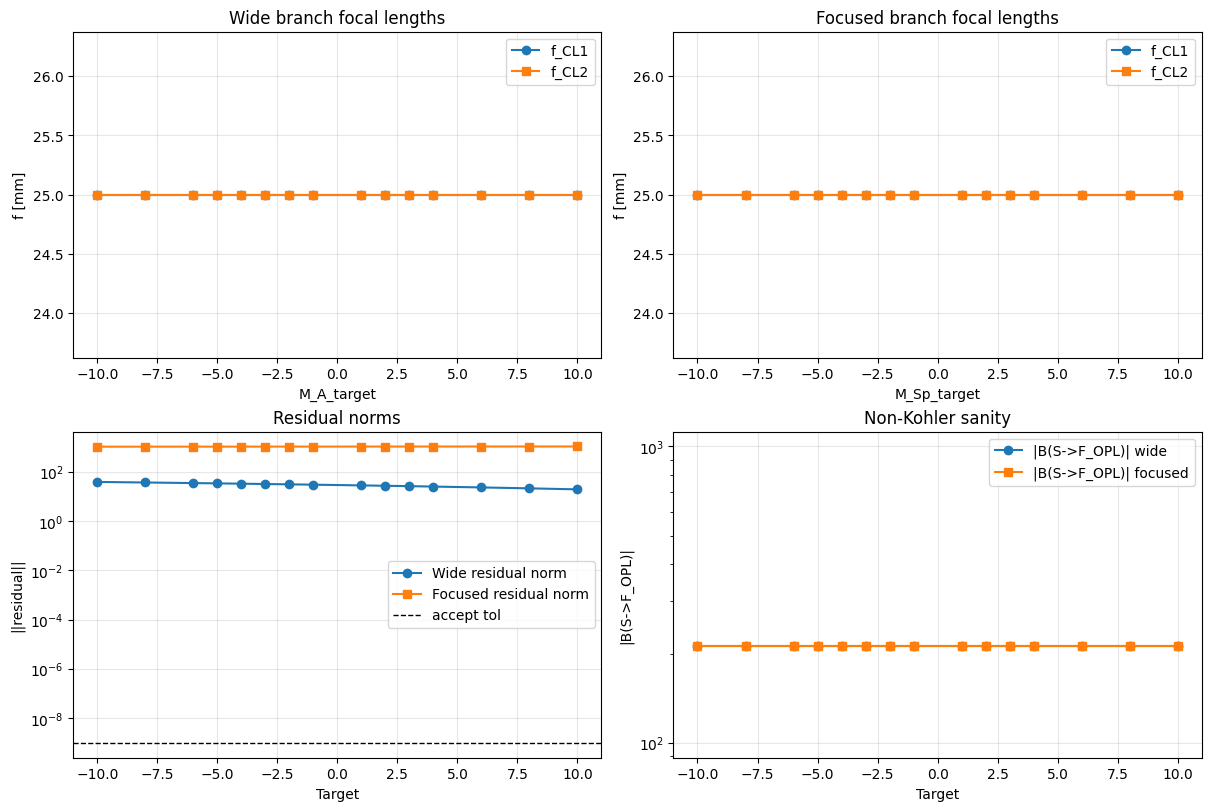

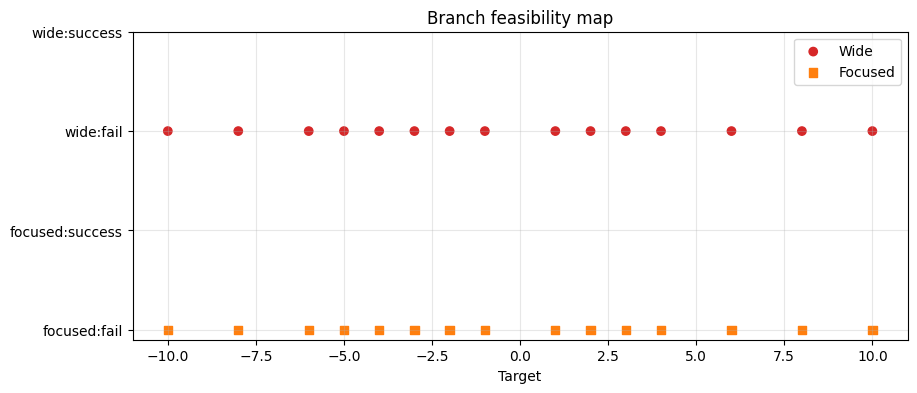

In [8]:
def _extract(results):
    t = np.array([r["target"] for r in results], dtype=float)
    f1 = np.array([r["f_CL1"] for r in results], dtype=float)
    f2 = np.array([r["f_CL2"] for r in results], dtype=float)
    rn = np.array([max(r["residual_norm"], 1e-20) for r in results], dtype=float)
    ok = np.array([r["success"] for r in results], dtype=bool)
    bf = np.array([abs(r["B_SFOPL"]) for r in results], dtype=float)
    return t, f1, f2, rn, ok, bf


tw, f1w, f2w, rnw, okw, bfw = _extract(wide_results)
tf, f1f, f2f, rnf, okf, bff = _extract(focused_results)

fig, axs = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

axs[0, 0].plot(tw, 1e3 * f1w, "o-", label="f_CL1")
axs[0, 0].plot(tw, 1e3 * f2w, "s-", label="f_CL2")
axs[0, 0].set_title("Wide branch focal lengths")
axs[0, 0].set_xlabel("M_A_target")
axs[0, 0].set_ylabel("f [mm]")
axs[0, 0].grid(True, alpha=0.3)
axs[0, 0].legend()

axs[0, 1].plot(tf, 1e3 * f1f, "o-", label="f_CL1")
axs[0, 1].plot(tf, 1e3 * f2f, "s-", label="f_CL2")
axs[0, 1].set_title("Focused branch focal lengths")
axs[0, 1].set_xlabel("M_Sp_target")
axs[0, 1].set_ylabel("f [mm]")
axs[0, 1].grid(True, alpha=0.3)
axs[0, 1].legend()

axs[1, 0].semilogy(tw, rnw, "o-", label="Wide residual norm")
axs[1, 0].semilogy(tf, rnf, "s-", label="Focused residual norm")
axs[1, 0].axhline(cfg_non_kohler["residual_tol_accept"], color="k", ls="--", lw=1.0, label="accept tol")
axs[1, 0].set_title("Residual norms")
axs[1, 0].set_xlabel("Target")
axs[1, 0].set_ylabel("||residual||")
axs[1, 0].grid(True, alpha=0.3)
axs[1, 0].legend()

axs[1, 1].semilogy(tw, bfw, "o-", label="|B(S->F_OPL)| wide")
axs[1, 1].semilogy(tf, bff, "s-", label="|B(S->F_OPL)| focused")
axs[1, 1].set_title("Non-Kohler sanity")
axs[1, 1].set_xlabel("Target")
axs[1, 1].set_ylabel("|B(S->F_OPL)|")
axs[1, 1].grid(True, alpha=0.3)
axs[1, 1].legend()

plt.show()

# Optional branch existence map
plt.figure(figsize=(10, 4))
plt.scatter(tw, np.where(okw, 1.0, 0.0), c=np.where(okw, "tab:green", "tab:red"), label="Wide", marker="o")
plt.scatter(tf, np.where(okf, -1.0, -2.0), c=np.where(okf, "tab:blue", "tab:orange"), label="Focused", marker="s")
plt.yticks([1.0, 0.0, -1.0, -2.0], ["wide:success", "wide:fail", "focused:success", "focused:fail"])
plt.xlabel("Target")
plt.title("Branch feasibility map")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Optional multistart scatter for one probe in each branch
for space, title in [(wide_space, "Wide"), (focused_space, "Focused")]:
    if space is None:
        continue
    raw = space["raw_results"]
    if not raw:
        continue
    x0_f1 = np.array([1e3 * r["x0"][0] for r in raw], dtype=float)
    x0_f2 = np.array([1e3 * r["x0"][1] for r in raw], dtype=float)
    c = np.array([r["residual_norm"] for r in raw], dtype=float)

    plt.figure(figsize=(5, 4))
    sc = plt.scatter(x0_f1, x0_f2, c=np.log10(np.maximum(c, 1e-20)), cmap="viridis", s=24)
    plt.colorbar(sc, label="log10 residual norm")
    plt.xlabel("seed f_CL1 [mm]")
    plt.ylabel("seed f_CL2 [mm]")
    plt.title(f"{title} multistart seed landscape (target={space['target']})")
    plt.grid(True, alpha=0.3)
    plt.show()


In [9]:
print("Acceptance checks summary")

wide_ok = [r for r in wide_results if r["success"]]
foc_ok = [r for r in focused_results if r["success"]]

print(f"- Wide branch successes: {len(wide_ok)}/{len(wide_results)}")
print(f"- Focused branch successes: {len(foc_ok)}/{len(focused_results)}")

if wide_ok:
    print("- Wide max |B|:", float(np.max([abs(r["B"]) for r in wide_ok])))
    print("- Wide max |A-target|:", float(np.max([abs(r["A"] - r["target"]) for r in wide_ok])))
if foc_ok:
    print("- Focused max |B|:", float(np.max([abs(r["B"]) for r in foc_ok])))
    print("- Focused max |A-target|:", float(np.max([abs(r["A"] - r["target"]) for r in foc_ok])))

if wide_ok or foc_ok:
    bf_all = [abs(r["B_SFOPL"]) for r in wide_ok + foc_ok]
    print("- Non-Kohler sanity median |B(S->F_OPL)|:", float(np.median(bf_all)))
    print("- Non-Kohler sanity min |B(S->F_OPL)|:", float(np.min(bf_all)))


Acceptance checks summary
- Wide branch successes: 0/15
- Focused branch successes: 0/15
